# Multivariate Regression Epidemics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
cwd = os.getcwd()
print(cwd)

c:\Users\danie\Documents\GitHub\thesis\modelling


In [3]:
df = pd.read_csv('../Data/gold/epidemics.csv')
df.head()

,week,dengue,zika,chik,var,date,tavg,tmin,tmax,prcp,...,google_pharmacy,google_symptom,co,dew,humidity,no2,o3,pm10,pm25,so2
0,2020-03-23,949,3.0,1.0,351.0,2020-03-23,20.003080,14.529673,25.878470,1.866561,...,6,44,6.007143,11.964286,82.078571,7.164286,18.142857,48.857143,118.285714,0.742857
1,2020-03-30,1006,1.0,4.0,275.0,2020-03-30,20.310320,15.607637,25.801951,4.628407,...,6,40,5.992857,12.285714,79.671429,6.228571,13.057143,25.214286,63.214286,0.628571
2,2020-04-06,931,3.0,2.0,212.0,2020-04-06,20.567575,15.800335,25.874548,3.028124,...,6,38,4.335714,12.678571,79.557143,4.700000,11.757143,15.214286,37.285714,0.614286
3,2020-04-13,883,1.0,0.0,188.0,2020-04-13,19.564572,14.112981,25.608096,2.240946,...,5,31,5.028571,11.714286,82.707143,7.000000,12.092857,31.571429,74.785714,0.642857
4,2020-04-20,879,3.0,3.0,195.0,2020-04-20,19.833153,14.608703,25.966335,4.637722,...,5,29,5.207143,11.928571,83.142857,7.192857,9.607143,23.071429,53.500000,0.442857


# Wrangle

In [4]:
df.columns

Index(['week', 'dengue', 'zika', 'chik', 'var', 'date', 'tavg', 'tmin', 'tmax',
       'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician',
       'google_hospital', 'google_pharmacy', 'google_symptom', 'co', 'dew',
       'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2'],
      dtype='object')

In [5]:
tarteg_cols = ['dengue', 'zika', 'chik', 'var']
for col in tarteg_cols:
    df['cum_'+ col ] = np.cumsum(df[col])

In [6]:
df['cum_dengue_t_1'] = df['cum_dengue'].shift(-1)
df['cum_zika_t_1'] = df['cum_zika'].shift(-1)
df['cum_chik_t_1'] = df['cum_chik'].shift(-1)
df['cum_var_t_1'] = df['cum_var'].shift(-1)


In [7]:
print(df['cum_dengue_t_1'].isnull().sum(), 'Nans for dengue +1')
print(df['cum_zika_t_1'].isnull().sum(), 'Nans for zika + 1')
print(df['cum_chik_t_1'].isnull().sum(), 'Nans for chikungunya +1')
print(df['cum_var_t_1'].isnull().sum(), 'Nans for chickenpox +1')

1 Nans for dengue +1
1 Nans for zika + 1
1 Nans for chikungunya +1
1 Nans for chickenpox +1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   week              197 non-null    object 
 1   dengue            197 non-null    int64  
 2   zika              197 non-null    float64
 3   chik              197 non-null    float64
 4   var               197 non-null    float64
 5   date              197 non-null    object 
 6   tavg              197 non-null    float64
 7   tmin              197 non-null    float64
 8   tmax              197 non-null    float64
 9   prcp              197 non-null    float64
 10  wdir              197 non-null    float64
 11  wspd              197 non-null    float64
 12  pres              197 non-null    float64
 13  mob_index         197 non-null    float64
 14  google_physician  197 non-null    int64  
 15  google_hospital   197 non-null    int64  
 16  google_pharmacy   197 non-null    int64  
 1

In [9]:
# drop nans
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 196 entries, 0 to 195
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   week              196 non-null    object 
 1   dengue            196 non-null    int64  
 2   zika              196 non-null    float64
 3   chik              196 non-null    float64
 4   var               196 non-null    float64
 5   date              196 non-null    object 
 6   tavg              196 non-null    float64
 7   tmin              196 non-null    float64
 8   tmax              196 non-null    float64
 9   prcp              196 non-null    float64
 10  wdir              196 non-null    float64
 11  wspd              196 non-null    float64
 12  pres              196 non-null    float64
 13  mob_index         196 non-null    float64
 14  google_physician  196 non-null    int64  
 15  google_hospital   196 non-null    int64  
 16  google_pharmacy   196 non-null    int64  
 17  go

In [10]:
# convert date to numeric
df['date'] = pd.to_datetime(df['date'])
df['date_numeric'] = df['date'].apply(lambda x: x.timestamp())

In [11]:
df_og = df.copy()

# Regression Framework

In [12]:
targets = ['cum_dengue_t_1', 'cum_zika_t_1', 'cum_chik_t_1', 'cum_var_t_1']

## OLS

In [13]:

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model    import LinearRegression
from sklearn.metrics         import mean_squared_error, r2_score
df = df_og.copy()

           target        rmse        r2
0  cum_dengue_t_1  246.079313  0.999865
1    cum_zika_t_1    1.452210  0.959236
2    cum_chik_t_1    1.221641  0.986253
3     cum_var_t_1   78.185029  0.999867
target      cum_chik_t_1  cum_dengue_t_1  cum_var_t_1  cum_zika_t_1
date                                                               
2020-03-23      4.211699     1897.819630   627.545878      5.167965
2020-03-30      7.581698     2890.654374   862.397903      6.237535
2020-04-06      8.859158     3797.396868  1038.688233      8.379593
2020-04-13      9.165622     4644.642682  1195.060900     10.117531
2020-04-20     11.837851     5486.880936  1392.052010     13.247433


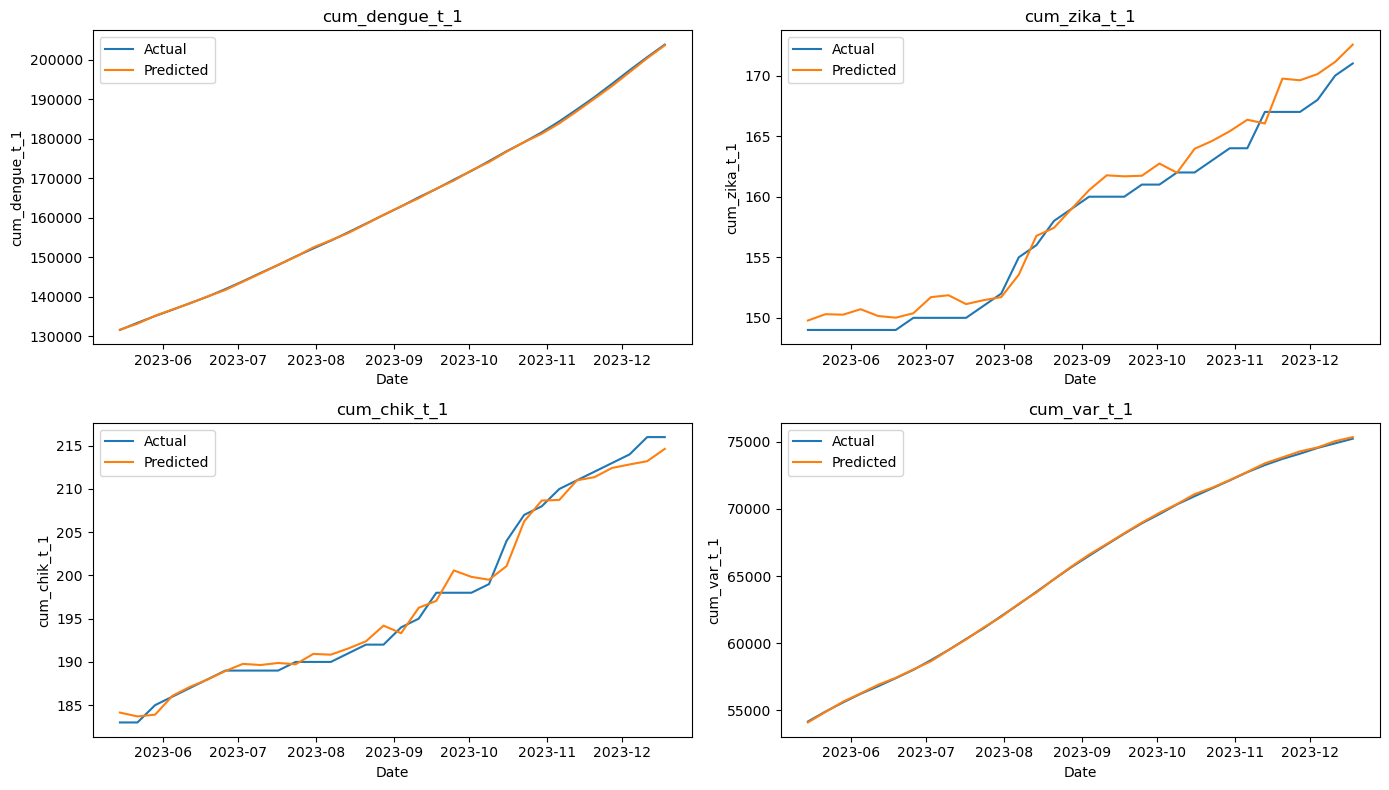

In [14]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['cum_dengue_t_1', 'cum_zika_t_1', 'cum_chik_t_1', 'cum_var_t_1']

results       = []   # per‑target metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 1.1  Copy & drop rows where the current target is NaN
    df_tgt = df.copy()
    df_tgt = df_tgt.dropna(subset=[tgt]).sort_values('date').reset_index(drop=True)

    if len(df_tgt) < 20:                # tiny series? skip
        print(f"[{tgt}] skipped (only {len(df_tgt)} non‑NaN rows)")
        continue

    # ---- 1.2  Features / target
    y = df_tgt[tgt]
    X = (df_tgt
         .drop(columns=targets + ['date'])        # remove all target cols + date
         .select_dtypes(include='number'))        # numeric predictors only

    # ---- 1.3  Time‑series split: last fold is hold‑out
    outer_split = TimeSeriesSplit(n_splits=5)
    train_idx, test_idx = list(outer_split.split(X))[-1]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']

    # ---- 1.4  Fit OLS
    ols = LinearRegression()
    ols.fit(X_train, y_train)

    # ---- 1.5  Predict + metrics
    y_pred_test  = ols.predict(X_test)
    y_pred_train = ols.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"target": tgt, "rmse": rmse, "r2": r2})

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test) for this target
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values  (date index, target columns)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  2 × 2 subplot grid (one panel per target)
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

# Hide any unused subplot (if fewer than 4 targets were modelled)
for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [15]:
fitted_df.to_csv('../results/OLS_epidemics.csv', index = True)

## Lasso

In [26]:

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline      import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model  import LassoCV

df = df_og.copy()

           target        rmse        r2     alpha
0  cum_dengue_t_1  467.109292  0.999513  0.001000
1    cum_zika_t_1    0.995657  0.980838  0.017433
2    cum_chik_t_1    1.247683  0.985660  0.001000
3     cum_var_t_1  276.650333  0.998331  0.001000
target      cum_chik_t_1  cum_dengue_t_1  cum_var_t_1  cum_zika_t_1
date                                                               
2020-03-23      4.153848     1775.805999   622.472041      4.883402
2020-03-30      7.509225     2735.860146   805.061217      6.156849
2020-04-06      8.815536     3721.756567  1009.459089      8.515652
2020-04-13      9.055895     4439.484520  1085.988584      9.938518
2020-04-20     11.760442     5344.150617  1296.895055     13.264680


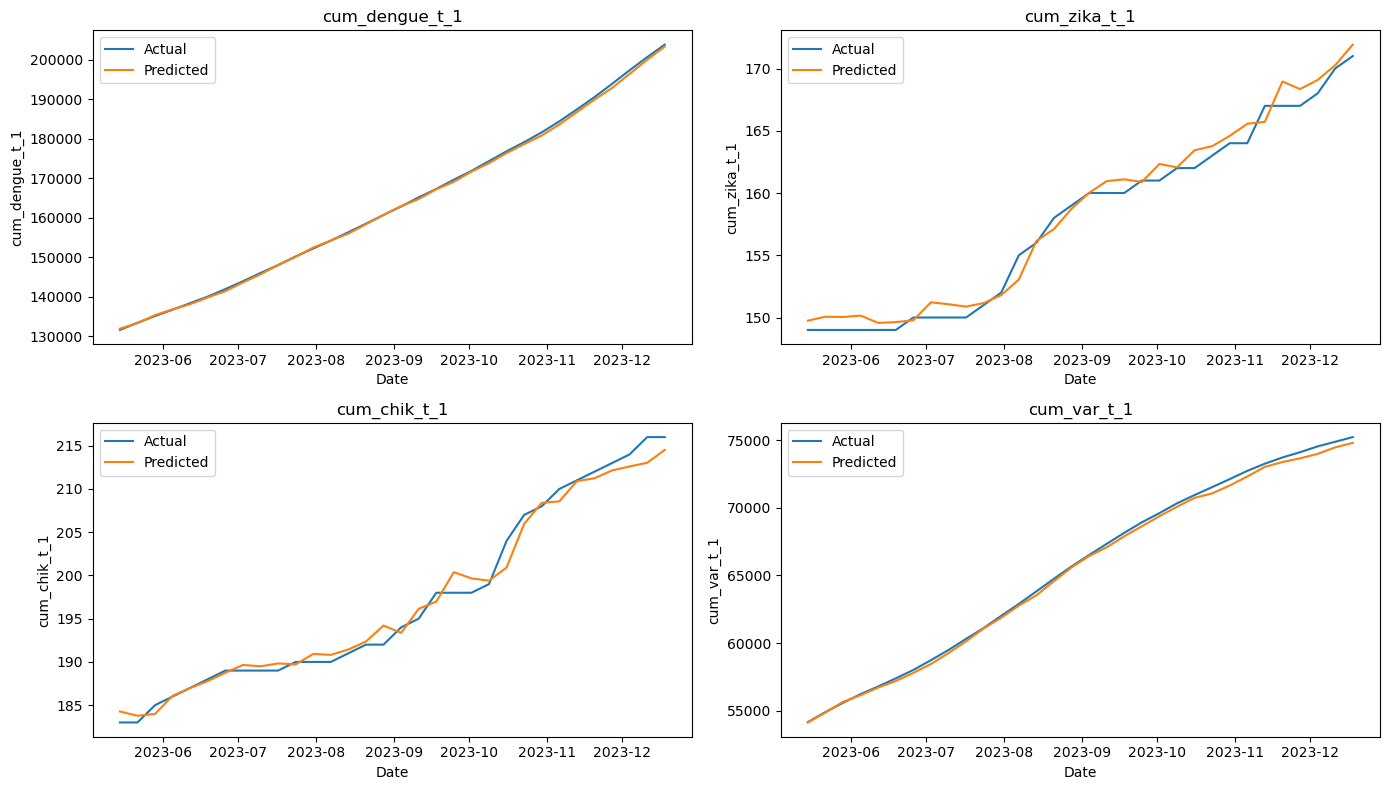

In [27]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['cum_dengue_t_1', 'cum_zika_t_1', 'cum_chik_t_1', 'cum_var_t_1']

results       = []   # metrics per target
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values (train + test)

# -------------------------------------------------------------
# 1.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 1.1  Drop rows where THIS target is NaN
    df_tgt = (df.copy()
                .dropna(subset=[tgt])
                .sort_values('date')
                .reset_index(drop=True))

    if len(df_tgt) < 20:                            # too few points?
        print(f"[{tgt}] skipped (only {len(df_tgt)} non‑NaN rows)")
        continue

    # ---- 1.2  Features / target
    y = df_tgt[tgt]
    X = (df_tgt
         .drop(columns=targets + ['date'])          # drop ALL target cols + date
         .select_dtypes(include='number'))          # numeric predictors

    # ---- 1.3  Time‑series split: last fold = test
    outer_split = TimeSeriesSplit(n_splits=5)
    train_idx, test_idx = list(outer_split.split(X))[-1]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: StandardScaler ➜ LassoCV
    inner_cv = TimeSeriesSplit(n_splits=3)
    lasso_pipe = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model",  LassoCV(alphas=np.logspace(-3, 3, 30),
                           cv=inner_cv,
                           random_state=42,
                           max_iter=5000))
    ])

    lasso_pipe.fit(X_train, y_train)
    best_alpha = lasso_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = lasso_pipe.predict(X_test)
    y_pred_train = lasso_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"target": tgt, "rmse": rmse, "r2": r2, "alpha": best_alpha})

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values  (index = date, columns = targets)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  2 × 2 subplot grid of Actual vs. Predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [28]:
fitted_df.to_csv('../results/Lasso_epidemics.csv', index = True)

## Ridge

In [29]:
from sklearn.linear_model  import RidgeCV
df = df_og.copy()


           target        rmse        r2     alpha
0  cum_dengue_t_1  322.434579  0.999768  0.001000
1    cum_zika_t_1    1.597147  0.950693  0.017433
2    cum_chik_t_1    1.196950  0.986803  0.004175
3     cum_var_t_1  100.401136  0.999780  0.001000
target      cum_chik_t_1  cum_dengue_t_1  cum_var_t_1  cum_zika_t_1
date                                                               
2020-03-23      4.161699     1918.774729   620.095557      5.225840
2020-03-30      7.573818     2896.978806   859.485175      6.312879
2020-04-06      8.858140     3802.903855  1034.435136      8.419250
2020-04-13      9.192814     4642.961914  1192.807374     10.210839
2020-04-20     11.876410     5474.296138  1395.576670     13.327391


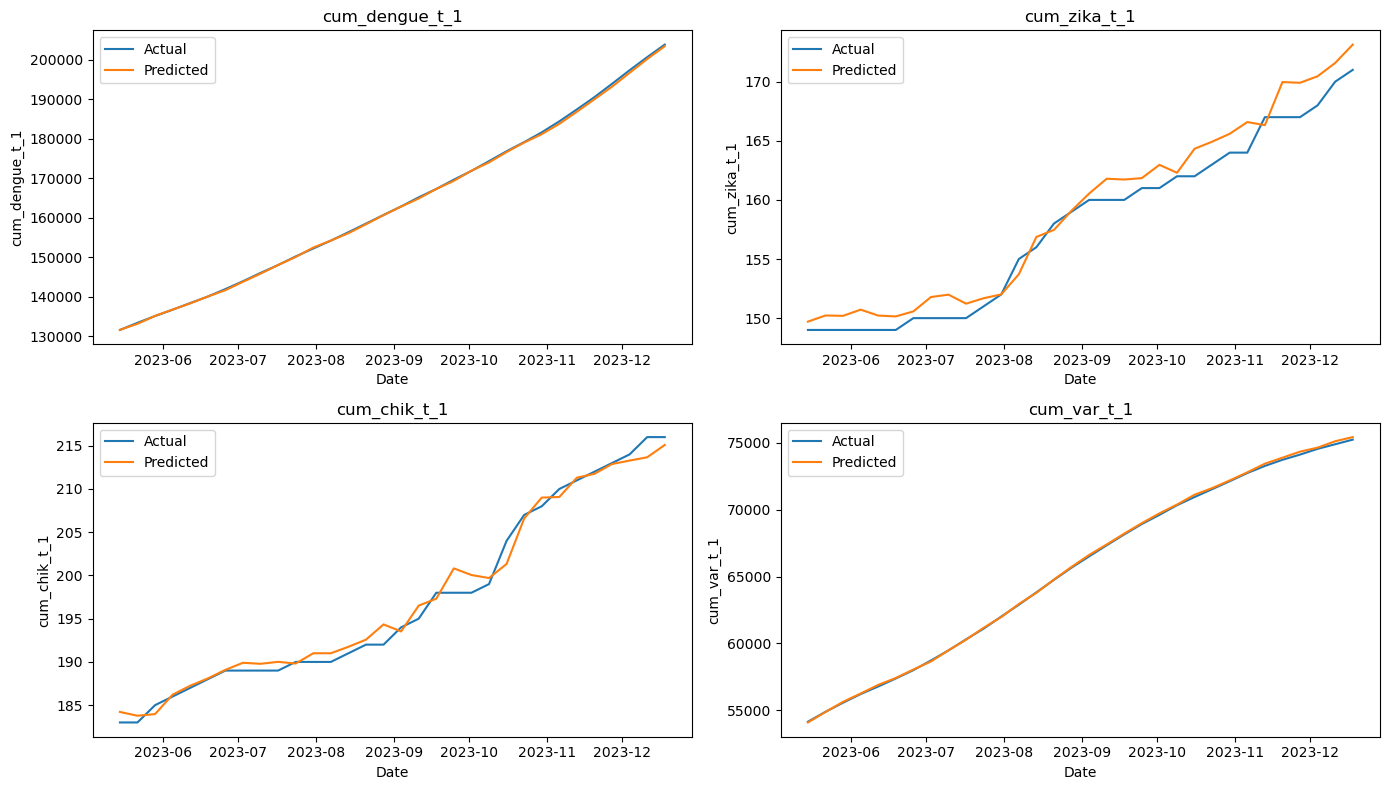

In [30]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['cum_dengue_t_1', 'cum_zika_t_1', 'cum_chik_t_1', 'cum_var_t_1']

results       = []   # metrics per target
plot_payload  = []   # hold-out curves
fit_records   = []   # fitted values (train + test)

# -------------------------------------------------------------
# 1.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 1.1  Drop rows where THIS target is NaN
    df_tgt = (df.copy()
                .dropna(subset=[tgt])
                .sort_values('date')
                .reset_index(drop=True))

    if len(df_tgt) < 20:                            # too few points?
        print(f"[{tgt}] skipped (only {len(df_tgt)} non-NaN rows)")
        continue

    # ---- 1.2  Features / target
    y = df_tgt[tgt]
    X = (df_tgt
         .drop(columns=targets + ['date'])          # drop ALL target cols + date
         .select_dtypes(include='number'))          # numeric predictors

    # ---- 1.3  Time-series split: last fold = test
    outer_split = TimeSeriesSplit(n_splits=5)
    train_idx, test_idx = list(outer_split.split(X))[-1]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: StandardScaler ➜ RidgeCV
    inner_cv   = TimeSeriesSplit(n_splits=3)
    ridge_pipe = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model",  RidgeCV(alphas=np.logspace(-3, 3, 30),
                           cv=inner_cv,
                           scoring='neg_root_mean_squared_error'))
    ])

    ridge_pipe.fit(X_train, y_train)
    best_alpha = ridge_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = ridge_pipe.predict(X_test)
    y_pred_train = ridge_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"target": tgt, "rmse": rmse, "r2": r2, "alpha": best_alpha})

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values  (index = date, columns = targets)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  2 × 2 subplot grid of Actual vs. Predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

# Hide unused panels (if any)
for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [31]:
fitted_df.to_csv('../results/Ridge_epidemics.csv', index = True)

## ElasticNet

In [32]:

from sklearn.linear_model  import ElasticNetCV
df = df_og.copy()

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.628e+07, tolerance: 2.134e+07
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.362e+06, tolerance: 4.121e+06
  model = cd_fast.enet_coordinate_descent(


           target         rmse        r2  alpha
0  cum_dengue_t_1  4387.469469  0.957036  0.001
1    cum_zika_t_1     1.925252  0.928353  0.001
2    cum_chik_t_1     3.276495  0.901109  0.001
3     cum_var_t_1   988.785358  0.978686  0.001
target      cum_chik_t_1  cum_dengue_t_1  cum_var_t_1  cum_zika_t_1
date                                                               
2020-03-23      3.530790     2785.991634   355.066197      5.430944
2020-03-30      7.471971     3139.582344   743.245616      6.542853
2020-04-06      8.900320     3941.362261   834.321038      8.557119
2020-04-13      9.556581     4475.158534  1053.845556     10.468701
2020-04-20     12.322951     4929.320903  1502.295945     13.533209


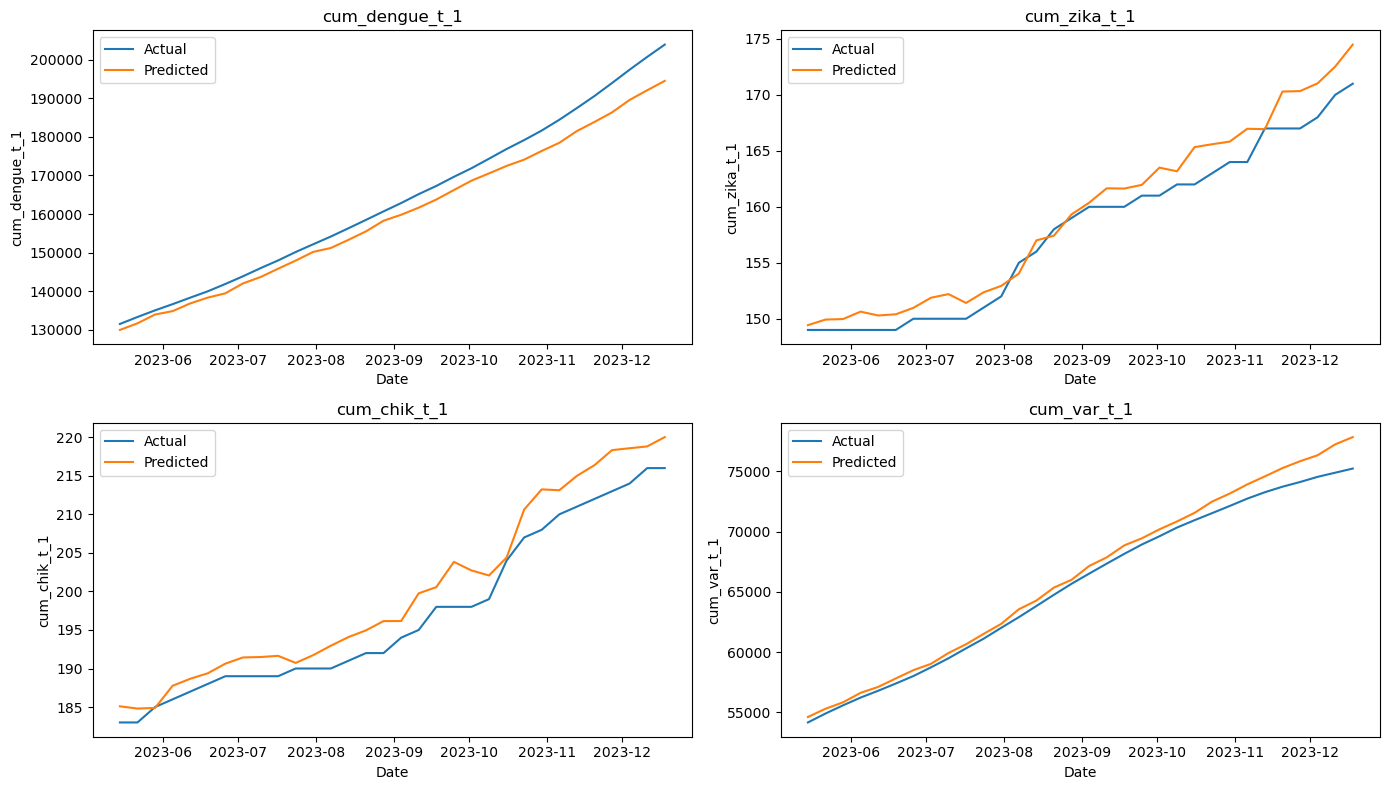

In [33]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['cum_dengue_t_1', 'cum_zika_t_1', 'cum_chik_t_1', 'cum_var_t_1']

results       = []   # metrics per target
plot_payload  = []   # hold-out curves
fit_records   = []   # fitted values (train + test)

# -------------------------------------------------------------
# 1.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 1.1  Drop rows where THIS target is NaN
    df_tgt = (df.copy()
                .dropna(subset=[tgt])
                .sort_values('date')
                .reset_index(drop=True))

    if len(df_tgt) < 20:
        print(f"[{tgt}] skipped (only {len(df_tgt)} non-NaN rows)")
        continue

    # ---- 1.2  Features / target
    y = df_tgt[tgt]
    X = (df_tgt
         .drop(columns=targets + ['date'])
         .select_dtypes(include='number'))

    # ---- 1.3  Time-series split: last fold = test
    outer_split = TimeSeriesSplit(n_splits=5)
    train_idx, test_idx = list(outer_split.split(X))[-1]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: StandardScaler ➜ ElasticNetCV (l1_ratio = 0.5)
    inner_cv = TimeSeriesSplit(n_splits=3)
    enet_pipe = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model",  ElasticNetCV(
                      l1_ratio     = 0.5,                      # 50-50 mix
                      alphas       = np.logspace(-3, 3, 30),
                      cv           = inner_cv,
                      random_state = 42,
                      max_iter     = 5000))
    ])

    enet_pipe.fit(X_train, y_train)
    best_alpha = enet_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = enet_pipe.predict(X_test)
    y_pred_train = enet_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"target": tgt, "rmse": rmse, "r2": r2, "alpha": best_alpha})

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values  (index = date, columns = targets)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  2 × 2 subplot grid of Actual vs. Predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [34]:
fitted_df.to_csv('../results/ElasticNet_epidemics.csv', index = True)

## Random Forest

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble        import RandomForestRegressor
df = df_og.copy()

In [ ]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['cum_dengue_t_1', 'cum_zika_t_1', 'cum_chik_t_1', 'cum_var_t_1']

results       = []   # metrics per target
plot_payload  = []   # hold-out curves
fit_records   = []   # fitted values (train + test)

# -------------------------------------------------------------
# 1.  Hyper-parameter grid  (coarse → refine later)
# -------------------------------------------------------------
param_grid = {
    "n_estimators":      [400, 800, 1200],
    "max_depth":         [None, 10, 20],
    "max_features":      ["sqrt", 0.6],
    "min_samples_leaf":  [1, 3, 5],
    "bootstrap":         [True, False]
}

# -------------------------------------------------------------
# 2.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 2.1  Drop rows where THIS target is NaN
    df_tgt = (df.copy()
                .dropna(subset=[tgt])
                .sort_values('date')
                .reset_index(drop=True))

    if len(df_tgt) < 20:                          # tiny series? skip
        print(f"[{tgt}] skipped (only {len(df_tgt)} non-NaN rows)")
        continue

    # ---- 2.2  Features / target
    y = df_tgt[tgt]
    X = (df_tgt
         .drop(columns=targets + ['date'])        # drop ALL targets + date
         .select_dtypes(include='number'))        # numeric predictors only

    # ---- 2.3  Time-series split: last fold is hold-out
    outer_split = TimeSeriesSplit(n_splits=5)
    train_idx, test_idx = list(outer_split.split(X))[-1]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']

    # ---- 2.4  Inner CV: grid-search random forest on training part
    inner_cv = TimeSeriesSplit(n_splits=3)
    rf_base  = RandomForestRegressor(random_state=42, n_jobs=-1)

    grid = GridSearchCV(
        estimator   = rf_base,
        param_grid  = param_grid,
        cv          = inner_cv,
        scoring     = "neg_root_mean_squared_error",
        n_jobs      = -1,
        verbose     = 0
    )
    grid.fit(X_train, y_train)
    best_rf     = grid.best_estimator_
    best_params = grid.best_params_

    # ---- 2.5  Predict + metrics
    y_pred_test  = best_rf.predict(X_test)
    y_pred_train = best_rf.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"target": tgt, "rmse": rmse, "r2": r2, "best_params": best_params})

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values  (index = date, columns = targets)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  2 × 2 subplot grid of Actual vs. Predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [ ]:
fitted_df.to_csv('../results/RF_epidemics.csv', index = True)

## Gradient Boosting

In [ ]:
from sklearn.ensemble        import GradientBoostingRegressor
df = df_og.copy()

In [ ]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['cum_dengue_t_1', 'cum_zika_t_1', 'cum_chik_t_1', 'cum_var_t_1']

results       = []   # metrics per target
plot_payload  = []   # hold-out curves
fit_records   = []   # fitted values (train + test)

# -------------------------------------------------------------
# 1.  Hyper-parameter grid  (coarse → refine once you see winners)
# -------------------------------------------------------------
param_grid = {
    "n_estimators":     [200, 400, 800],
    "learning_rate":    [0.03, 0.05, 0.1],
    "max_depth":        [2, 3, 4],
    "subsample":        [0.7, 0.9, 1.0],
    "min_samples_leaf": [1, 3, 5],
    "max_features":     ["sqrt", 0.6, None]
}

# -------------------------------------------------------------
# 2.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 2.1  Drop rows where THIS target is NaN
    df_tgt = (df.copy()
                .dropna(subset=[tgt])
                .sort_values('date')
                .reset_index(drop=True))

    if len(df_tgt) < 20:                          # tiny series? skip
        print(f"[{tgt}] skipped (only {len(df_tgt)} non-NaN rows)")
        continue

    # ---- 2.2  Features / target
    y = df_tgt[tgt]
    X = (df_tgt
         .drop(columns=targets + ['date'])        # drop ALL target cols + date
         .select_dtypes(include='number'))        # numeric predictors only

    # ---- 2.3  Time-series split: last fold is hold-out
    outer_split = TimeSeriesSplit(n_splits=5)
    train_idx, test_idx = list(outer_split.split(X))[-1]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']

    # ---- 2.4  Inner CV: grid-search GBM on training portion
    inner_cv = TimeSeriesSplit(n_splits=3)
    gb_base  = GradientBoostingRegressor(random_state=42)

    grid = GridSearchCV(
        estimator   = gb_base,
        param_grid  = param_grid,
        cv          = inner_cv,
        scoring     = "neg_root_mean_squared_error",
        n_jobs      = -1,
        verbose     = 0
    )
    grid.fit(X_train, y_train)
    best_gb     = grid.best_estimator_
    best_params = grid.best_params_

    # ---- 2.5  Predict + metrics
    y_pred_test  = best_gb.predict(X_test)
    y_pred_train = best_gb.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"target": tgt, "rmse": rmse, "r2": r2, "best_params": best_params})

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values  (index = date, columns = targets)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  2 × 2 subplot grid of Actual vs. Predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [ ]:
fitted_df.to_csv('../results/GB_epidemics.csv', index = True)

## SVM

In [ ]:
from sklearn.svm            import SVR
df = df_og.copy()

In [ ]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

targets = ['cum_dengue_t_1', 'cum_zika_t_1', 'cum_chik_t_1', 'cum_var_t_1']

results       = []   # metrics per target
plot_payload  = []   # hold-out curves
fit_records   = []   # fitted values (train + test)

# -------------------------------------------------------------
# 1.  Hyper-parameter grid for an RBF-kernel SVR
# -------------------------------------------------------------
param_grid = {
    "model__C":       [0.5, 1, 5, 20],       # overall regularisation
    "model__epsilon": [0.05, 0.1, 0.2],      # ε-insensitive zone
    "model__gamma":   ["scale", 0.01, 0.1, 1.0]   # kernel width
    # add "model__kernel": ["rbf", "linear"] if you want the grid to decide
}

# -------------------------------------------------------------
# 2.  Loop over target variables
# -------------------------------------------------------------
for tgt in targets:

    # ---- 2.1  Drop rows where THIS target is NaN
    df_tgt = (
        df.dropna(subset=[tgt])
          .sort_values('date')
          .reset_index(drop=True)
    )

    if len(df_tgt) < 20:
        print(f"[{tgt}] skipped (only {len(df_tgt)} non-NaN rows)")
        continue

    # ---- 2.2  Features / target
    y = df_tgt[tgt]
    X = (
        df_tgt
        .drop(columns=targets + ['date'])     # remove ALL target cols + date
        .select_dtypes(include='number')      # numeric predictors only
    )

    # ---- 2.3  Time-series split: last fold → hold-out
    outer_split = TimeSeriesSplit(n_splits=5)
    train_idx, test_idx = list(outer_split.split(X))[-1]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_tgt.loc[test_idx, 'date']

    # ---- 2.4  Pipeline: StandardScaler ➜ SVR + grid search
    inner_cv = TimeSeriesSplit(n_splits=3)

    svr_pipe = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model",  SVR(kernel="linear"))
        ]
    )

    grid = GridSearchCV(
        estimator   = svr_pipe,
        param_grid  = param_grid,
        cv          = inner_cv,
        scoring     = "neg_root_mean_squared_error",
        n_jobs      = -1,
        verbose     = 0,
    )
    grid.fit(X_train, y_train)

    best_svr    = grid.best_estimator_
    best_params = grid.best_params_

    # ---- 2.5  Predict + metrics
    y_pred_test  = best_svr.predict(X_test)
    y_pred_train = best_svr.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({
        "target":     tgt,
        "rmse":       rmse,
        "r2":         r2,
        "best_params": best_params
    })

    plot_payload.append({
        "target": tgt,
        "date":   dates_test,
        "y_true": y_test,
        "y_pred": y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_tgt.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":   df_tgt['date'],
            "target": tgt,
            "fitted": y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values (index = date, columns = targets)
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='target', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  2 × 2 subplot grid of Actual vs. Predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["target"])
    ax.set_xlabel("Date")
    ax.set_ylabel(payload["target"])
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [ ]:
fitted_df.to_csv('../results/SVM_epidemics.csv', index = True)

They depend almost exclusively on their lagged variables, so modelling as VAR is a good Idea / or any other time series approach as has been done until now